# Сравнение DFA на CPU и CUDA

Сравнение времени работы и результатов DFA с NumPy и CuPy.
Используются четыре длины гауссовского белого шума и 15 парных повторов.

In [1]:
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from visualization_toolkit.plots.boxplot import boxplot
from visualization_toolkit.styles.boxplot import (
    boxprops_filled,
    boxprops_filled_hatched,
)

project_dir = Path(".")
while not (project_dir / "StatTools").is_dir():
    parent = project_dir / ".."
    if parent.resolve() == project_dir.resolve():
        raise FileNotFoundError("Откройте ноутбук внутри FluctuationAnalysisTools.")
    project_dir = parent

sys.path.insert(0, str(project_dir.resolve()))
from StatTools.analysis.dfa import dfa


## Параметры эксперимента

In [2]:
SIZES = [1_000, 10_000, 100_000, 1_000_000]
REPEATS = 15
DEGREE = 2
N_INTEGRAL = 1
S_MIN = 5
RTOL = 1e-7
ATOL = 1e-10

## Измерение времени

Измеряется полный вызов DFA, включая передачу данных CPU–GPU.

In [3]:
def measure_dfa(data, backend):
    if backend == "cuda":
        cp.cuda.runtime.deviceSynchronize()

    start = perf_counter()
    scales, f2 = dfa(
        data, degree=DEGREE, n_integral=N_INTEGRAL,
        s_min=S_MIN, processes=1, backend=backend,
    )

    if backend == "cuda":
        cp.cuda.runtime.deviceSynchronize()

    elapsed = perf_counter() - start
    return elapsed, scales, f2

## Параметры

In [4]:
import cupy as cp

gpu_name = cp.cuda.runtime.getDeviceProperties(cp.cuda.Device().id)["name"]
if isinstance(gpu_name, bytes):
    gpu_name = gpu_name.decode()

parameters = {
    "sizes": SIZES,
    "repeats": REPEATS,
    "degree": DEGREE,
    "n_integral": N_INTEGRAL,
    "s_min": S_MIN,
    "rtol": RTOL,
    "atol": ATOL,
    "processes": 1,
    "signal": "Gaussian white noise",
    "dtype": "float64",
    "gpu": gpu_name,
    "numpy": np.__version__,
    "cupy": cp.__version__,
}

print("GPU:", gpu_name)
display(pd.Series(parameters, name="value").to_frame())


GPU: NVIDIA GeForce RTX 5080


,value
sizes,"[1000, 10000, 100000, 1000000]"
repeats,15
degree,2
n_integral,1
s_min,5
rtol,0.0
atol,0.0
processes,1
signal,Gaussian white noise
dtype,float64


## Запуск эксперимента

Для каждой длины создаём один случайный сигнал и передаём его обеим версиям DFA.
Перед замерами выполняем по одному прогреву на CPU и GPU.
В каждом повторе запускаем обе версии, меняя порядок запуска.

In [5]:
rng = np.random.default_rng()

signals = {}
dfa_results = {}
records = []

for n in SIZES:
    data = rng.standard_normal(n)
    signals[n] = data

    for backend in ["cpu", "cuda"]:
        print(f"N={n}: прогрев {backend}", flush=True)
        measure_dfa(data, backend)

    for repeat in range(1, REPEATS + 1):
        order = ["cpu", "cuda"] if repeat % 2 else ["cuda", "cpu"]
        measured = {}

        for backend in order:
            print(f"N={n}, повтор {repeat}/{REPEATS}, {backend}", flush=True)
            measured[backend] = measure_dfa(data, backend)
            print(f"Время: {measured[backend][0]:.3f} с", flush=True)

        cpu_time, cpu_scales, cpu_f2 = measured["cpu"]
        cuda_time, cuda_scales, cuda_f2 = measured["cuda"]

        np.testing.assert_array_equal(cpu_scales, cuda_scales)
        assert cpu_f2.shape == cuda_f2.shape and cpu_f2.size > 0
        assert np.isfinite(cpu_f2).all() and np.isfinite(cuda_f2).all()

        matches = bool(np.allclose(cuda_f2, cpu_f2, rtol=RTOL, atol=ATOL))

        dfa_results[(n, repeat)] = {
            "s_cpu": cpu_scales,
            "f2_cpu": cpu_f2,
            "s_cuda": cuda_scales,
            "f2_cuda": cuda_f2,
        }

        records.append({
            "size": n,
            "repeat": repeat,
            "first_backend": order[0],
            "cpu_time": cpu_time,
            "cuda_time": cuda_time,
            "max_abs_error": float(np.max(np.abs(cpu_f2 - cuda_f2))),
            "results_match": matches,
        })

        assert matches, "Результаты CPU/CUDA различаются больше допустимого."

results = pd.DataFrame(records)
results["speedup"] = results["cpu_time"] / results["cuda_time"]

print("Замеры завершены.")
display(results.head())
display(results.groupby("size").size().rename("completed_pairs").to_frame())


N=1000: прогрев cpu
N=1000: прогрев cuda
N=1000, повтор 1/15, cpu
Время: 0.001 с
N=1000, повтор 1/15, cuda
Время: 0.009 с
N=1000, повтор 2/15, cuda
Время: 0.009 с
N=1000, повтор 2/15, cpu
Время: 0.001 с
N=1000, повтор 3/15, cpu
Время: 0.001 с
N=1000, повтор 3/15, cuda
Время: 0.009 с
N=1000, повтор 4/15, cuda
Время: 0.008 с
N=1000, повтор 4/15, cpu
Время: 0.001 с
N=1000, повтор 5/15, cpu
Время: 0.001 с
N=1000, повтор 5/15, cuda
Время: 0.008 с
N=1000, повтор 6/15, cuda
Время: 0.008 с
N=1000, повтор 6/15, cpu
Время: 0.001 с
N=1000, повтор 7/15, cpu
Время: 0.001 с
N=1000, повтор 7/15, cuda
Время: 0.008 с
N=1000, повтор 8/15, cuda
Время: 0.008 с
N=1000, повтор 8/15, cpu
Время: 0.001 с
N=1000, повтор 9/15, cpu
Время: 0.001 с
N=1000, повтор 9/15, cuda
Время: 0.008 с
N=1000, повтор 10/15, cuda
Время: 0.008 с
N=1000, повтор 10/15, cpu
Время: 0.001 с
N=1000, повтор 11/15, cpu
Время: 0.001 с
N=1000, повтор 11/15, cuda
Время: 0.008 с
N=1000, повтор 12/15, cuda
Время: 0.008 с
N=1000, повтор 12/15, 

,size,repeat,first_backend,cpu_time,cuda_time,max_abs_error,results_match,speedup
0,1000,1,cpu,0.000548,0.008685,1.776357e-15,True,0.063122
1,1000,2,cuda,0.000712,0.008644,1.776357e-15,True,0.082417
2,1000,3,cpu,0.001089,0.008923,1.776357e-15,True,0.122022
3,1000,4,cuda,0.000804,0.008130,1.776357e-15,True,0.098852
4,1000,5,cpu,0.000660,0.008262,1.776357e-15,True,0.079899


,completed_pairs
size,
1000,15
10000,15
100000,15
1000000,15


## Результаты

In [6]:
assert results["results_match"].all(), "Нужно проверить расхождение CPU/CUDA."
assert (results[["cpu_time", "cuda_time"]] > 0).all().all()

display(results)


,size,repeat,first_backend,cpu_time,cuda_time,max_abs_error,results_match,speedup
0,1000,1,cpu,0.000548,0.008685,1.776357e-15,True,0.063122
1,1000,2,cuda,0.000712,0.008644,1.776357e-15,True,0.082417
2,1000,3,cpu,0.001089,0.008923,1.776357e-15,True,0.122022
3,1000,4,cuda,0.000804,0.008130,1.776357e-15,True,0.098852
4,1000,5,cpu,0.000660,0.008262,1.776357e-15,True,0.079899
5,1000,6,cuda,0.001030,0.008205,1.776357e-15,True,0.125512
6,1000,7,cpu,0.000701,0.008247,1.776357e-15,True,0.085024
7,1000,8,cuda,0.000853,0.007769,1.776357e-15,True,0.109822
8,1000,9,cpu,0.000574,0.008389,1.776357e-15,True,0.068471
9,1000,10,cuda,0.000744,0.008085,1.776357e-15,True,0.092029


## Сводные результаты

Рассчитываем среднее, медиану и стандартное отклонение времени работы.
Ускорение — время CPU, делённое на время GPU в том же повторе.
Если оно больше 1, GPU работает быстрее.
Также проверяем, совпадают ли результаты CPU и GPU в пределах заданных допусков.


In [7]:
times = results.melt(
    id_vars=["size", "repeat"],
    value_vars=["cpu_time", "cuda_time"],
    var_name="backend",
    value_name="seconds",
)
times["backend"] = times["backend"].map({
    "cpu_time": "cpu",
    "cuda_time": "cuda",
})

time_summary = times.groupby(["size", "backend"])["seconds"].agg(
    ["count", "mean", "median", "std", "min", "max"],
)
comparison = results.groupby("size").agg(
    median_speedup=("speedup", "median"),
    max_abs_error=("max_abs_error", "max"),
    results_match=("results_match", "all"),
)

display(time_summary)
display(comparison)


count      mean    median       std       min       max
size    backend                                                         
1000    cpu         15  0.000784  0.000753  0.000147  0.000548  0.001089
        cuda        15  0.008380  0.008373  0.000291  0.007769  0.008923
10000   cpu         15  0.003103  0.002969  0.000578  0.002487  0.004201
        cuda        15  0.015016  0.014882  0.000718  0.014271  0.016958
100000  cpu         15  0.025006  0.025485  0.001593  0.021062  0.026768
        cuda        15  0.020889  0.020695  0.000650  0.020240  0.022575
1000000 cpu         15  0.436251  0.436974  0.006873  0.421048  0.450396
        cuda        15  0.037647  0.035975  0.004441  0.034191  0.048408

,median_speedup,max_abs_error,results_match
size,,,
1000,0.092029,1.776357e-15,True
10000,0.197471,3.552714e-14,True
100000,1.208377,1.364242e-12,True
1000000,12.161831,8.185452e-12,True


## Статистическое сравнение

Для каждого повтора вычисляем разницу во времени работы CPU и GPU.
Тестом Шапиро—Уилка проверяем, похоже ли распределение этих разностей на нормальное.
Парным t-тестом проверяем, различается ли среднее время работы двух версий DFA.
Для t-теста предполагаем, что повторы независимы, а разности имеют нормальное распределение.
При p ≥ 0.05 тест Шапиро не обнаружил отклонения от нормальности, но не доказал её.


In [8]:
test_records = []

for n, group in results.groupby("size"):
    difference = group["cpu_time"] - group["cuda_time"]
    shapiro_p = np.nan
    ttest_p = np.nan

    if len(group) >= 3 and np.std(difference) > 0:
        shapiro_p = stats.shapiro(difference).pvalue

    if len(group) >= 2 and np.std(difference) > 0:
        ttest_p = stats.ttest_rel(
            group["cpu_time"],
            group["cuda_time"],
        ).pvalue

    test_records.append({
        "size": n,
        "pairs": len(group),
        "mean_difference": difference.mean(),
        "shapiro_p": shapiro_p,
        "ttest_p": ttest_p,
    })

test_results = pd.DataFrame(test_records)
display(test_results)


,size,pairs,mean_difference,shapiro_p,ttest_p
0,1000,15,-0.007596,0.984805,7.822581e-21
1,10000,15,-0.011913,0.731231,1.123802e-19
2,100000,15,0.004117,0.491484,3.181808e-07
3,1000000,15,0.398604,0.980609,5.898070e-25


## Графики

Boxplot времени и ускорения.
Коробка показывает центральные 50% значений, линия внутри — медиану.

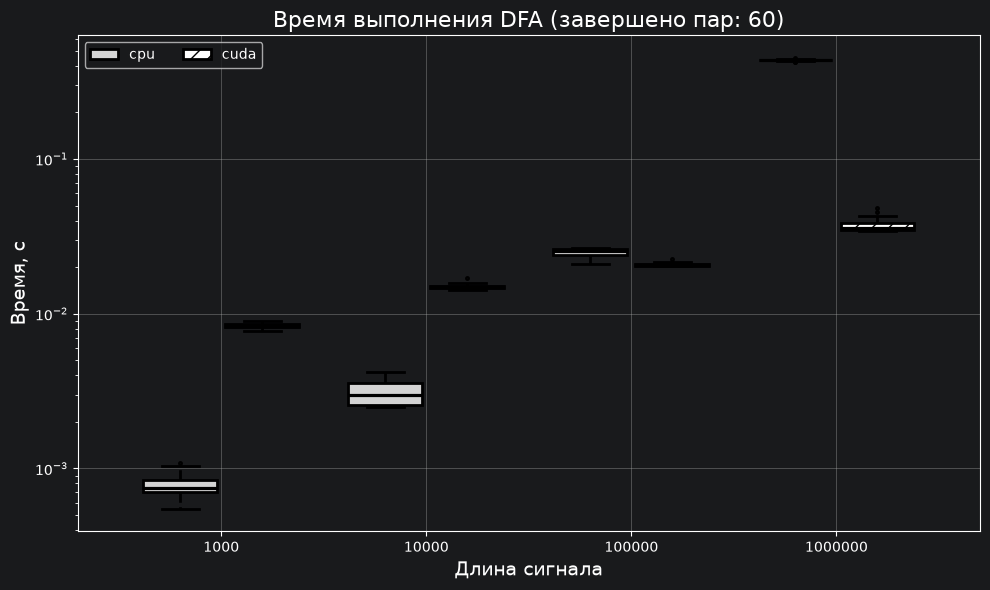

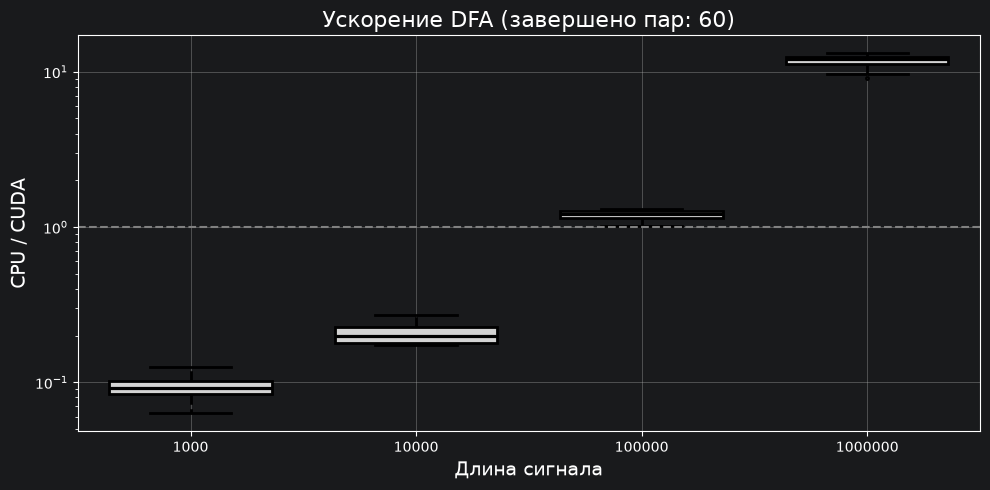

In [9]:
from matplotlib.patches import Patch

# Совместимость строковых меток с visualization-toolkit.
times["backend"] = times["backend"].astype(object)

styles = {
    "cpu": boxprops_filled(),
    "cuda": boxprops_filled_hatched(hatch="//"),
}
label = f"завершено пар: {len(results)}"

fig, axes = boxplot(
    data=times,
    x="size",
    y="seconds",
    hue="backend",
    styles=styles,
    logy=True,
    x_label="Длина сигнала",
    y_label="Время, с",
    title=f"Время выполнения DFA ({label})",
    axes_fontsize=14,
    title_fontsize=16,
    fig_size=(10, 6),
)

for legend in list(fig.legends):
    legend.remove()

handles = [
    Patch(label=backend, **style["boxprops"])
    for backend, style in styles.items()
]
axes[0].legend(handles=handles, loc="upper left", ncol=2, fontsize=10)
fig.tight_layout()
plt.show()
plt.close(fig)

fig, axes = boxplot(
    data=results,
    x="size",
    y="speedup",
    styles={None: boxprops_filled()},
    logy=True,
    x_label="Длина сигнала",
    y_label="CPU / CUDA",
    title=f"Ускорение DFA ({label})",
    axes_fontsize=14,
    title_fontsize=16,
    fig_size=(10, 5),
)
axes[0].axhline(1, color="gray", linestyle="--")
fig.tight_layout()
plt.show()
plt.close(fig)
